<a href="https://colab.research.google.com/github/michalis0/DataScience_and_MachineLearning/blob/master/Assignments/Part%201/Assignment_part_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DSML investigation:
### You are part of the Suisse Impossible Mission Force, or SIMF for short. You need to uncover a rogue agent that is trying to steal sensitive information.

### Your mission, should you choose to accept it, is to find that agent before any classified information gets stolen. Good luck!


## Assignment part one

Airport security confiscated a laptop of a spy, which was later given to you. The laptop contains some documents that might be useful in the investigation process. You retrieve those documents and want to analyse them. Our intelligence shows that the person that we are looking for has visited the USA between Sept 2019 to Oct 2020. He is currently working undercover.


### Getting to know our data

We have retrieved from the laptop the following file:
- A list of suspects
- The flight records of these potential suspects



In [348]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
userRecords = pd.read_csv("https://raw.githubusercontent.com/michalis0/DataScience_and_MachineLearning/refs/heads/master/Assignments/Part%201/data/userRecords.csv")
travelRecords = pd.read_csv("https://raw.githubusercontent.com/michalis0/DataScience_and_MachineLearning/refs/heads/master/Assignments/Part%201/data/flightRecords.csv")

In [349]:
userRecords

,UserID,first_name,last_name,birthday,country,marital_status,number_of_kids,employment
0,317991,Lu***,Al*****,29.07.03,AR,1,2.0,Web Designer
1,241892,Ma****,Ro*******,10.11.99,AR,1,0.0,Banker
2,303376,Fr****,Ac****,25.07.84,AR,1,0.0,Kitchen staff
3,761992,Fr****,Go***,20.03.70,AR,1,0.0,Teaching Assistant
4,373318,Jo***,Ro***,05.10.71,AR,1,0.0,Administrative employee
...,...,...,...,...,...,...,...,...
952,218415,Bu******,Mo******,22.01.01,ZA,0,1.0,Web Designer
953,173906,Th*****,Mo******,06.11.61,ZA,0,2.0,Web Designer
954,178685,Mi*****,Bu*******,29.05.53,ZA,0,1.0,Professor
955,200865,Si*******,Na****,16.12.62,ZA,0,0.0,Web Designer


In [350]:
travelRecords[travelRecords["userID"] == 317991]

,flightName,departure,destination,date,userID
0,KX65826,AR,IT,20.01.10,317991
1,CL12336,IT,MT,16.06.10,317991
2,YN106988,MT,SE,08.05.11,317991
3,CB58289,SE,EE,08.11.11,317991
4,SX625101,EE,AZ,17.11.11,317991
5,FI81778,AZ,ES,19.01.12,317991
6,WL73165,ES,RU,24.02.12,317991
7,NG103876,RU,JP,28.06.12,317991
8,IX62714,JP,AT,24.07.12,317991
9,BT46823,AT,GB,25.08.12,317991


#### Shape of the data

Let's first check how many rows and columns (features) are in the user records

In [351]:
#Your code here
userRecords.shape

(957, 8)

**Q1. How many rows are there in the user records dataset?**
There are 957 rows.


#### Check out the first few rows
Print the first few rows of the user records dataset and check them. Note that to protect innocent people, the name of the suspects have been censored, those will be revealed once number of potential suspects decreases.


In [352]:
#Your code here
userRecords.head()

,UserID,first_name,last_name,birthday,country,marital_status,number_of_kids,employment
0,317991,Lu***,Al*****,29.07.03,AR,1,2.0,Web Designer
1,241892,Ma****,Ro*******,10.11.99,AR,1,0.0,Banker
2,303376,Fr****,Ac****,25.07.84,AR,1,0.0,Kitchen staff
3,761992,Fr****,Go***,20.03.70,AR,1,0.0,Teaching Assistant
4,373318,Jo***,Ro***,05.10.71,AR,1,0.0,Administrative employee


#### Column/feature names
print the list of columns in the user records dataset.

In [353]:
#Your code here
userRecords.columns

Index(['UserID', 'first_name', 'last_name', 'birthday', 'country',
       'marital_status', 'number_of_kids', 'employment'],
      dtype='str')

#### Duplicates
Check if there are any duplicate entries in the user records dataset.

__Remark__: If there are two rows in the dataset that have the same value for __all of the columns__, we consider this as a duplicate.

In [354]:
#Your code here
userRecords.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
952    False
953    False
954    False
955    False
956    False
Length: 957, dtype: bool

Show all the duplicated rows in the user records dataset.

__Hint:__ use the method `duplicated(keep=False)` to get all occurrences of the duplicated rows.

In [355]:
#Your code here
userRecords[userRecords.duplicated(keep=False) == True]

,UserID,first_name,last_name,birthday,country,marital_status,number_of_kids,employment
18,100684,Ma*****,Me****,17.06.76,AR,NaN,0.0,Administrative employee
19,100684,Ma*****,Me****,17.06.76,AR,NaN,0.0,Administrative employee
47,910382,Ni***,El****,21.03.75,AZ,NaN,0.0,Administrative employee
165,910382,Ni***,El****,21.03.75,AZ,NaN,0.0,Administrative employee
276,610518,An*****,An******,15.02.53,DK,1,NaN,Manager
290,610518,An*****,An******,15.02.53,DK,1,NaN,Manager


**Q2. Are there any duplicate entries in the user records dataset?**
*Note: Duplicate entries refer to two or more rows where all the values across every column are identical.*
Yes

**Q3. How many duplicate entries are in the user records dataset?**
(Remark: for instance: there are 2 duplicate "entries" in the following list: '1 ,2, 1, 3, 3, 4, 5'. It's 1 and 3).
There are 3 duplicated entries in the user dataset

Drop the duplicate entries in the user records dataset.

In [356]:
#Your code here
userRecords.drop_duplicates()

,UserID,first_name,last_name,birthday,country,marital_status,number_of_kids,employment
0,317991,Lu***,Al*****,29.07.03,AR,1,2.0,Web Designer
1,241892,Ma****,Ro*******,10.11.99,AR,1,0.0,Banker
2,303376,Fr****,Ac****,25.07.84,AR,1,0.0,Kitchen staff
3,761992,Fr****,Go***,20.03.70,AR,1,0.0,Teaching Assistant
4,373318,Jo***,Ro***,05.10.71,AR,1,0.0,Administrative employee
...,...,...,...,...,...,...,...,...
952,218415,Bu******,Mo******,22.01.01,ZA,0,1.0,Web Designer
953,173906,Th*****,Mo******,06.11.61,ZA,0,2.0,Web Designer
954,178685,Mi*****,Bu*******,29.05.53,ZA,0,1.0,Professor
955,200865,Si*******,Na****,16.12.62,ZA,0,0.0,Web Designer


### Spies often use false identities with fabricated data.

#### This suggests that if certain data points occur with statistically improbable frequency, they might be fabricated.

In this part we are going to verify if there are birthdates that have been reused an unusual amount of times.

Let's first ensure that the birthday column in the user records dataset has the correct format (datetime):


In [357]:
#Check the data type of each feature
#Your code here
userRecords.dtypes


UserID              int64
first_name            str
last_name             str
birthday              str
country               str
marital_status        str
number_of_kids    float64
employment            str
dtype: object

Convert the column `birthday` to datetime if necessary

In [358]:
#Your code here
userRecords['birthday'] = pd.to_datetime(userRecords["birthday"], format="%d.%m.%y")
userRecords['birthday']


0     2003-07-29
1     1999-11-10
2     1984-07-25
3     1970-03-20
4     1971-10-05
         ...    
952   2001-01-22
953   2061-11-06
954   2053-05-29
955   2062-12-16
956   2050-02-24
Name: birthday, Length: 957, dtype: datetime64[us]

Find the list of birthdays that are duplicated/reused in the dataset

In [359]:
#Your code here
userRecords['birthday'][userRecords['birthday'].duplicated(keep=False) == True]


6     2067-07-24
13    2004-11-30
18    1976-06-17
19    1976-06-17
34    2057-06-25
46    1991-12-02
47    1975-03-21
74    2067-07-24
112   2057-12-24
150   1983-03-15
153   2068-09-22
160   1975-01-28
165   1975-03-21
183   2068-09-22
186   2055-01-08
191   2062-07-07
209   2055-01-08
241   2057-12-18
276   2053-02-15
288   2057-12-24
290   2053-02-15
305   1970-03-18
312   2068-10-09
329   2004-11-30
355   2057-06-25
370   1978-11-21
393   1983-03-15
396   1991-12-02
399   2060-03-26
481   1983-08-26
501   1970-04-06
511   2060-06-23
516   1978-11-21
538   1999-08-09
557   1999-09-12
570   2060-03-26
592   1999-08-09
623   2054-03-26
627   1992-06-01
630   1992-06-01
647   1992-06-01
666   1970-03-18
668   1992-06-01
715   2060-06-23
722   2062-07-07
723   1983-08-26
772   1970-04-06
790   2057-12-18
807   1975-01-28
810   2068-10-09
838   1999-09-12
950   2054-03-26
Name: birthday, dtype: datetime64[us]

Let's count how many people have their birthday on the same day among the duplicated birthdays.

In [360]:
#Your code here
duplicated_birthdays = userRecords['birthday'][userRecords['birthday'].duplicated(keep=False)]
aggregated_birthdays = duplicated_birthdays.value_counts().sort_values(ascending=False)
display(aggregated_birthdays)

birthday
1992-06-01    4
2057-12-18    2
1999-09-12    2
1999-08-09    2
2060-06-23    2
1970-04-06    2
1983-08-26    2
2060-03-26    2
1978-11-21    2
2068-10-09    2
1970-03-18    2
2053-02-15    2
2062-07-07    2
2067-07-24    2
2055-01-08    2
1975-01-28    2
2068-09-22    2
1983-03-15    2
2057-12-24    2
1975-03-21    2
1991-12-02    2
2057-06-25    2
1976-06-17    2
2004-11-30    2
2054-03-26    2
Name: count, dtype: int64

**Q4. What is the most common birthday in the dataset?**
The most common birthday is 1992-06-01

**Q5. How many users have their birthdays on that day (the most common birthday)?**
4 users have their birthdays on 1992-06-01

We can consider that there is no suspicious discrepancy through birthdays.


#### We have reasons to believe that the suspect works very thoroughly, so he would make sure that the fabricated data about his identity is complete in order for his operation to run smoothly.
#### Therefore, we can exclude the people with incomplete information from the list of potential suspects.

Count how many null values are there in each column of the user records dataset. You can call `isnull()` and `sum()` to get a count of how many null values are there in each column.

In [361]:
#Your code here
userRecords.isnull().sum()


UserID              0
first_name          1
last_name           1
birthday            1
country             0
marital_status    104
number_of_kids    153
employment          1
dtype: int64

If you encounter any null values in the dataset, be sure to exclude those entries from the suspect list.

In [362]:
#Your code here
userRecords.dropna(inplace=True)
userRecords.isnull().sum()


UserID            0
first_name        0
last_name         0
birthday          0
country           0
marital_status    0
number_of_kids    0
employment        0
dtype: int64

### Linking the user records to the flight records

We will now proceed to identify the users who were in the USA from Sept 1st, 2019 to Oct 31st, 2020.

We will merge the flight records with the user records in order to ensure that users who have been unsuspected in the previous step are not considered.

In [363]:
#check the user records dataset
userRecords.head()

,UserID,first_name,last_name,birthday,country,marital_status,number_of_kids,employment
0,317991,Lu***,Al*****,2003-07-29,AR,1,2.0,Web Designer
1,241892,Ma****,Ro*******,1999-11-10,AR,1,0.0,Banker
2,303376,Fr****,Ac****,1984-07-25,AR,1,0.0,Kitchen staff
3,761992,Fr****,Go***,1970-03-20,AR,1,0.0,Teaching Assistant
4,373318,Jo***,Ro***,1971-10-05,AR,1,0.0,Administrative employee


In [364]:
#check the flight records dataset
travelRecords.head()

,flightName,departure,destination,date,userID
0,KX65826,AR,IT,20.01.10,317991
1,CL12336,IT,MT,16.06.10,317991
2,YN106988,MT,SE,08.05.11,317991
3,CB58289,SE,EE,08.11.11,317991
4,SX625101,EE,AZ,17.11.11,317991


[Merging](https://pandas.pydata.org/docs/user_guide/merging.html) the two datasets:

*Hint: Use the above questions to identify on what feature to merge the datasets*

The result should contain the features flightName, Departure, Arrival,  Date, UserID, first_name, last_name, etc.

In [365]:
#Your code here
user_flights_data = pd.merge(userRecords, travelRecords, left_on="UserID", right_on="userID", how="left")
user_flights_data

,UserID,first_name,last_name,birthday,country,marital_status,number_of_kids,employment,flightName,departure,destination,date,userID
0,317991,Lu***,Al*****,2003-07-29,AR,1,2.0,Web Designer,KX65826,AR,IT,20.01.10,317991.0
1,317991,Lu***,Al*****,2003-07-29,AR,1,2.0,Web Designer,CL12336,IT,MT,16.06.10,317991.0
2,317991,Lu***,Al*****,2003-07-29,AR,1,2.0,Web Designer,YN106988,MT,SE,08.05.11,317991.0
3,317991,Lu***,Al*****,2003-07-29,AR,1,2.0,Web Designer,CB58289,SE,EE,08.11.11,317991.0
4,317991,Lu***,Al*****,2003-07-29,AR,1,2.0,Web Designer,SX625101,EE,AZ,17.11.11,317991.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19033,200865,Si*******,Na****,2062-12-16,ZA,0,0.0,Web Designer,IY61324,PL,ZA,01.09.20,200865.0
19034,200865,Si*******,Na****,2062-12-16,ZA,0,0.0,Web Designer,JO46672,ZA,DZ,20.07.21,200865.0
19035,200865,Si*******,Na****,2062-12-16,ZA,0,0.0,Web Designer,HX1014810,DZ,CR,22.01.22,200865.0
19036,200865,Si*******,Na****,2062-12-16,ZA,0,0.0,Web Designer,DL869109,CR,GT,28.04.22,200865.0


Remember, our suspect operates meticulously, ensuring that there are no null values in any entries.

In [366]:
#Your code here
user_flights_data.dropna(inplace=True)
user_flights_data

,UserID,first_name,last_name,birthday,country,marital_status,number_of_kids,employment,flightName,departure,destination,date,userID
0,317991,Lu***,Al*****,2003-07-29,AR,1,2.0,Web Designer,KX65826,AR,IT,20.01.10,317991.0
1,317991,Lu***,Al*****,2003-07-29,AR,1,2.0,Web Designer,CL12336,IT,MT,16.06.10,317991.0
2,317991,Lu***,Al*****,2003-07-29,AR,1,2.0,Web Designer,YN106988,MT,SE,08.05.11,317991.0
3,317991,Lu***,Al*****,2003-07-29,AR,1,2.0,Web Designer,CB58289,SE,EE,08.11.11,317991.0
4,317991,Lu***,Al*****,2003-07-29,AR,1,2.0,Web Designer,SX625101,EE,AZ,17.11.11,317991.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19033,200865,Si*******,Na****,2062-12-16,ZA,0,0.0,Web Designer,IY61324,PL,ZA,01.09.20,200865.0
19034,200865,Si*******,Na****,2062-12-16,ZA,0,0.0,Web Designer,JO46672,ZA,DZ,20.07.21,200865.0
19035,200865,Si*******,Na****,2062-12-16,ZA,0,0.0,Web Designer,HX1014810,DZ,CR,22.01.22,200865.0
19036,200865,Si*******,Na****,2062-12-16,ZA,0,0.0,Web Designer,DL869109,CR,GT,28.04.22,200865.0


Let's now identify the users who has **travelled to** the United States (US) between the 1st of september 2019 and the 31st of october 2020.

*Note that the travel date is not in datetime format.*

In [367]:
#Your code here
user_flights_data["date"] = pd.to_datetime(user_flights_data["date"], format="%d.%m.%y")
suspected_user_travels = user_flights_data.loc[
    (user_flights_data["date"].between('2019-09-01', '2020-10-31'))
    & (user_flights_data["destination"] == "US")
]
just_suspected_travelers = suspected_user_travels[["UserID", "first_name", "last_name", "employment"]].drop_duplicates()
display(just_suspected_travelers)

,UserID,first_name,last_name,employment
246,468560,Ga******,Fe*******,Lawyer
463,255830,Ch*******,Be****,Professor
958,861915,Ay***,Al*****,Doctor
2289,220420,Ma*****,So****,Web Designer
2702,297653,Br***,Wo**,Lawyer
4089,710764,Ra*****,He*******,Manager
4897,267733,Sø***,Ma****,Kitchen staff
5349,429697,Li**,Re****,Administrative employee
7179,649131,Ju***,Wi****,Banker
7451,481578,Br****,De*****,Administrative employee


(34, 4)

**Q6. How many suspects travelled to the US between the 1st of September 2019 and the 31st of October 2020?**
34 distinct travelers flew to the US during this timeframe

**Q7. Which users are included in the remaining list of suspects who traveled to the US between the 1st of September 2019 and the 31st of October 2020?** Choose from the answers on Moodle.

## [Data visualisation ](https://pandas.pydata.org/docs/user_guide/visualization.html)

 Suisse Impossible Mission Force is happy with the result and would like to have some visual aid to make a profile of the potential suspects.

Let's create a pie chart to visualize the employment distribution among the suspects who traveled to US between September 1st, 2019, and October 31st, 2020.

<Axes: >

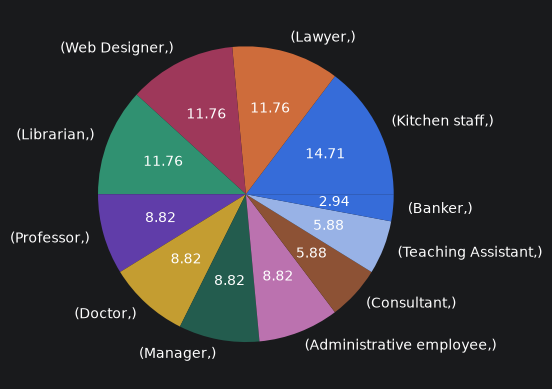

In [368]:
#Your code here
grouped_jobs = just_suspected_travelers[["employment"]].value_counts().sort_values(ascending=False)
grouped_jobs.plot.pie(autopct="%.2f")

**Q8. Which profession is the least represented among the suspects who traveled to US between September 1st, 2019, and October 31st, 2020?**
 Choose from the answers on Moodle.
 Banker


## Journey length

The Suisse Impossible Mission Force suspects that the rogue agent is an anomaly within his declared employment category, particularly in terms of the number of days he spent at destinations compared to his peers.

To identify such deviations, we can employ boxplots for each employment category, allowing us to visually identify outliers in the data.

First, let's construct two tables: one for the dates of arrival and another for the dates of departure. Utilize the existing dataset to extract these dates based on the 'destination' and 'departure' columns. Ensure that both the arrival and departure dates are within the period the suspect is believed to have been in the US, which is from September 2019 to October 2020.

In [369]:
# For this step we will need the information not only about the fights to the US, 
# but also about the flights taken from the US
# Your code here
departures = user_flights_data[(user_flights_data["date"].between('2019-09-01', '2020-10-31')) & (user_flights_data["departure"] == "US")]

arrivals = user_flights_data[(user_flights_data["date"].between('2019-09-01', '2020-10-31')) & (user_flights_data["destination"] == "US")]

display(departures)
display(arrivals)


,UserID,first_name,last_name,birthday,country,marital_status,number_of_kids,employment,flightName,departure,destination,date,userID
464,255830,Ch*******,Be****,2059-12-26,AT,1,1.0,Professor,FR31198,US,NL,2020-10-07,255830.0
1298,265615,Er**,La*****,2067-03-13,BE,1,2.0,Web Designer,DI331075,US,NO,2019-11-17,265615.0
3108,494514,Al*******,Ca****,1979-04-02,CL,1,2.0,Consultant,OQ110536,US,BG,2019-10-10,494514.0
3958,744124,Ma****,Ca******,1972-05-01,CR,1,0.0,Lawyer,UM753101,US,CA,2020-01-13,744124.0
4090,710764,Ra*****,He*******,1976-05-27,CR,0,4.0,Manager,TA510851,US,GB,2019-10-04,710764.0
4809,648234,An****,Mø****,1975-02-19,DK,0,2.0,Kitchen staff,FX88473,US,PH,2019-09-27,648234.0
5466,412064,Ол***,Se**,1974-07-30,EE,0,0.0,Banker,JG784107,US,IE,2019-10-21,412064.0
7452,481578,Br****,De*****,2063-07-31,GT,1,0.0,Administrative employee,WA86122,US,HU,2020-07-02,481578.0
7666,804662,Er***,He*******,2054-08-08,GT,1,1.0,Consultant,VY46165,US,SE,2020-08-05,804662.0
7716,661944,Je****,Ša***,1990-08-15,HR,1,1.0,Lawyer,UK631018,US,IN,2019-09-01,661944.0


,UserID,first_name,last_name,birthday,country,marital_status,number_of_kids,employment,flightName,departure,destination,date,userID
246,468560,Ga******,Fe*******,2060-04-18,AR,1,2.0,Lawyer,MG891910,AR,US,2020-07-16,468560.0
463,255830,Ch*******,Be****,2059-12-26,AT,1,1.0,Professor,OO3731010,CA,US,2020-04-10,255830.0
958,861915,Ay***,Al*****,1978-02-26,AZ,0,1.0,Doctor,GU84573,ES,US,2020-02-10,861915.0
2289,220420,Ma*****,So****,1984-12-23,BR,0,3.0,Web Designer,TF469810,IT,US,2020-03-17,220420.0
2702,297653,Br***,Wo**,2068-09-22,CA,1,0.0,Lawyer,MX97137,FR,US,2020-07-23,297653.0
4089,710764,Ra*****,He*******,1976-05-27,CR,0,4.0,Manager,NY87398,BE,US,2019-09-17,710764.0
4897,267733,Sø***,Ma****,1998-09-14,DK,0,0.0,Kitchen staff,HX23943,CO,US,2020-10-10,267733.0
5349,429697,Li**,Re****,2059-07-28,EE,1,3.0,Administrative employee,JE532410,CH,US,2020-06-26,429697.0
7179,649131,Ju***,Wi****,1991-07-04,GB,1,3.0,Banker,LY781032,BR,US,2020-04-18,649131.0
7451,481578,Br****,De*****,2063-07-31,GT,1,0.0,Administrative employee,PP35996,HU,US,2020-05-03,481578.0


We can keep on both of these tables the user ID, employment, and departure date / arrival date.

In [370]:
#Your code here
departures = departures[["userID", "employment", "date"]]
arrivals = arrivals[["userID", "employment", "date"]]

display(departures.shape)
display(arrivals.shape)

(33, 3)

We can now join the two tables on user ID.

In [371]:
#Your code here
journeys = pd.merge(departures, arrivals, left_on="userID", right_on="userID", how="outer").sort_values(by=["userID"])
journeys["date_x"] = journeys["date_x"].fillna(pd.Timestamp("2020-10-31"))
journeys["date_y"] = journeys["date_y"].fillna(pd.Timestamp("2019-09-01"))
journeys["employment_x"] = journeys["employment_x"].fillna(journeys["employment_y"])
journeys["employment_y"] = journeys["employment_y"].fillna(journeys["employment_x"])
journeys.head()
display(journeys)

,userID,employment_x,date_x,employment_y,date_y
0,123699.0,Lawyer,2020-10-31,Lawyer,2020-07-19
1,139646.0,Doctor,2020-07-29,Doctor,2019-11-10
2,178685.0,Professor,2019-10-18,Professor,2019-09-01
3,220420.0,Web Designer,2020-10-31,Web Designer,2020-03-17
4,255830.0,Professor,2020-10-07,Professor,2020-04-10
5,265615.0,Web Designer,2019-11-17,Web Designer,2019-09-01
6,267733.0,Kitchen staff,2020-10-31,Kitchen staff,2020-10-10
7,287607.0,Kitchen staff,2020-06-30,Kitchen staff,2020-02-16
8,297653.0,Lawyer,2020-10-31,Lawyer,2020-07-23
9,409055.0,Librarian,2020-10-31,Librarian,2020-10-07


We can now create a new feature called journey_length representing the difference between departure date and arrival date.

*Hint: Ensure that the journey_length is in the right format*

In [374]:
#Your code here
journey_lengths = journeys
journey_lengths["journey_length"] = (journeys["date_x"] - journeys["date_y"]).dt.days
journey_lengths.sort_values("journey_length")
display(journey_lengths.sort_values("employment_x"))

,userID,employment_x,date_x,employment_y,date_y,journey_length
38,795804.0,Administrative employee,2020-06-16,Administrative employee,2019-09-01,289
18,481578.0,Administrative employee,2020-07-02,Administrative employee,2020-05-03,60
37,785994.0,Administrative employee,2020-10-31,Administrative employee,2020-06-09,144
15,429697.0,Administrative employee,2020-10-31,Administrative employee,2020-06-26,127
26,649131.0,Banker,2020-10-31,Banker,2020-04-18,196
12,412064.0,Banker,2019-10-21,Banker,2019-09-01,50
19,494514.0,Consultant,2019-10-10,Consultant,2019-09-01,39
39,804662.0,Consultant,2020-08-05,Consultant,2020-01-14,204
29,707686.0,Consultant,2020-10-31,Consultant,2020-01-17,288
46,931749.0,Doctor,2019-11-10,Doctor,2019-09-01,70


*Sidenote: if you get negative journey length, what would be your explanation to that?*
That the user left during the given window (2019-09-01 ~ 2020-10-31) and arrived later to stay further from the given window

We can now create the boxplots where the x-axis represents each profession and the y-axis corresponds to the journey length.

journey_length    Axes(0.125,0.11;0.775x0.77)
dtype: object

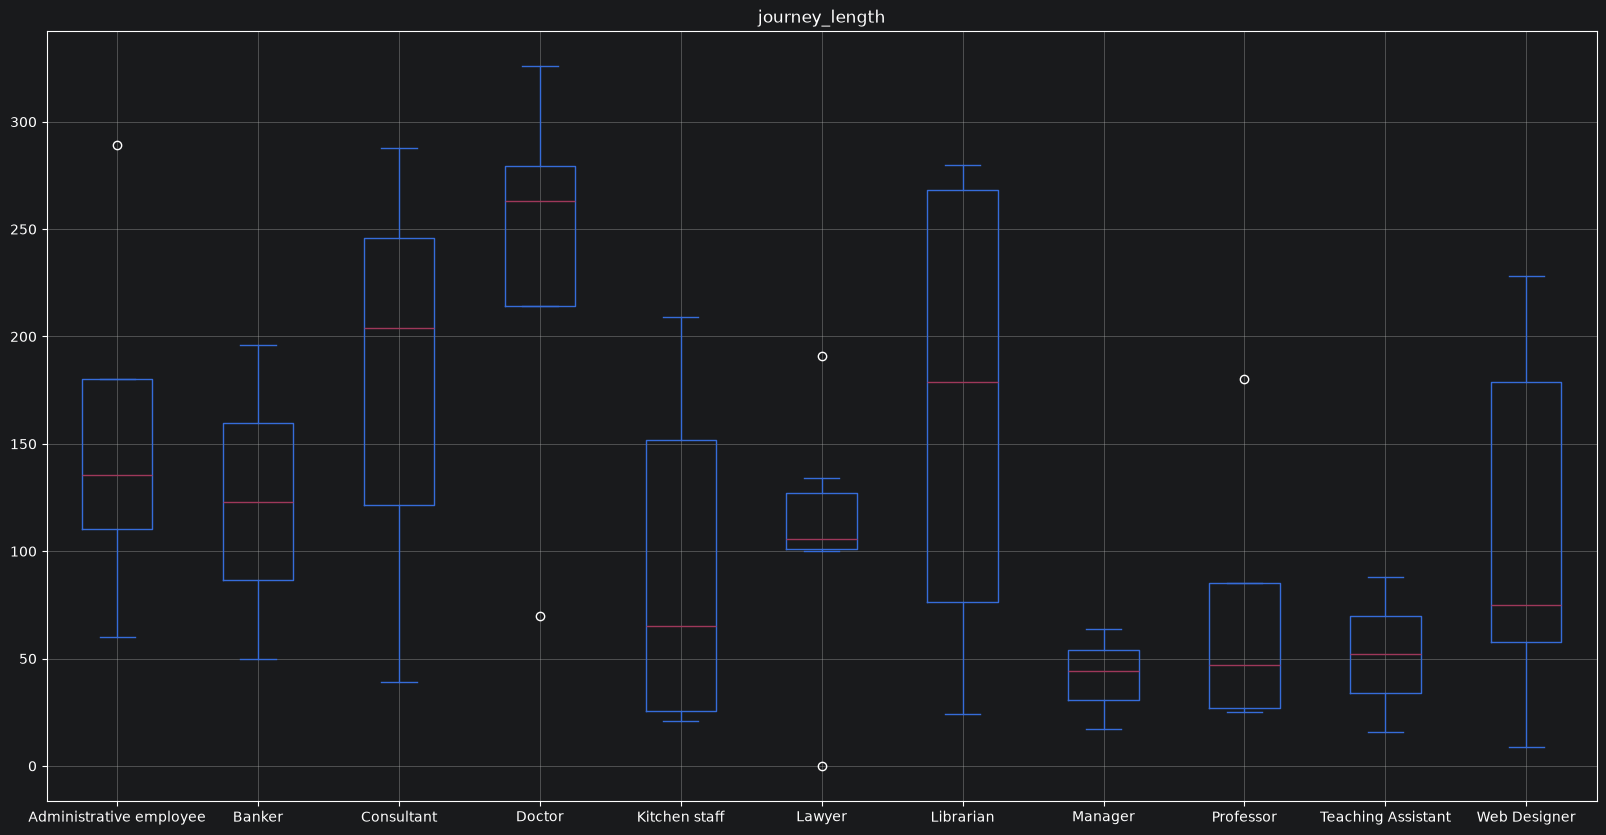

In [376]:
#Your code here
graph_data = journey_lengths[["employment_x", "journey_length"]]
graph_data.plot.box(by="employment_x", figsize=(20, 10), grid=True)

**Q9. Which profession has the most staggering outlier?**
(Meaning that the outlier value is the farthest away from the corresponding boxplot.)
Doctor

### SIMF is satisfied with your work but believes the current data is inconclusive.

Your investigation will continue when more intelligence comes in...

**Don't forget to complete the moodle quiz ([Assignment Q1](https://moodle.unil.ch/mod/quiz/view.php?id=1744562)) and submit your code ([Code Q1](https://moodle.unil.ch/mod/assign/view.php?id=1744563)) on Moodle before Monday 30.09.2024.**